# GliZNet — Full Benchmark Evaluation

Evaluates **GliZNet** (DeBERTa-v3-base backbone, checkpoint-850) on the same 13 datasets used in the GLiClass benchmark paper, reporting **macro F1** for direct comparison.

**Datasets**: CR, SST-2, SST-5, IMDb, 20-Newsgroups, Enron Spam, MASSIVE, Banking77, Financial PhraseBank, AG News, Emotion, CAP-SOTU, Rotten Tomatoes

| Model | Avg macro F1 |
|---|---|
| GLiClass-large-v3.0 | 0.7193 |
| GLiClass-base-v3.0 | 0.6764 |
| GLiClass-modern-large-v3.0 | 0.6197 |
| GLiClass-modern-base-v3.0 | 0.5577 |
| GLiClass-edge-v3.0 | 0.4900 |
| deberta-v3-large-zeroshot-v2.0 | 0.6821 |
| deberta-v3-base-zeroshot-v2.0 | 0.6559 |
| **GliZNet-deberta-v3-base (ours)** | **?** |


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset, ClassLabel
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

from gliznet import ZeroShotClassificationPipeline
from gliznet.tokenizer import GliZNETTokenizer
from gliznet.model import GliZNetForSequenceClassification

DEVICE     = "cuda:0" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "../results/deberta-v3-base_20260427_081605/checkpoint-1914"
BATCH_SIZE = 32

print(f"Device : {DEVICE}")
print(f"Model  : {MODEL_PATH}")

Device : cuda:0
Model  : ../results/deberta-v3-base_20260427_081605/checkpoint-1914


In [2]:
# Load GliZNet pipeline
pipeline = ZeroShotClassificationPipeline.from_pretrained(
    MODEL_PATH,
    classification_type="multi-class",
    device=DEVICE,
)
print("✓ GliZNet loaded")

# Sanity check
out = pipeline("I absolutely loved this film!", ["positive", "negative", "neutral"])
for ls in out.labels:
    print(f"  {ls.label:<12} {ls.score:.3f}")

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

✓ GliZNet loaded
  positive     0.988
  negative     0.006
  neutral      0.006


## Dataset loading helpers

In [3]:
def get_test_split(ds):
    """Return the test (or fallback validation/train) split."""
    for key in ("test", "validation", "train"):
        if key in ds:
            return ds[key]
    raise ValueError("No usable split found")


def resolve_labels(split, label_col):
    """Return (class_names: list[str], int_to_str callable).
    Handles ClassLabel features and plain int/string columns.
    Classes are always returned as strings so the tokenizer never receives ints.
    """
    feat = split.features.get(label_col)
    if isinstance(feat, ClassLabel):
        classes = feat.names          # already list[str]
        to_str = lambda i: classes[i]
    else:
        raw_classes = sorted(set(split[label_col]))
        classes = [str(c) for c in raw_classes]
        to_str = lambda x: str(x)
    return classes, to_str


def prepare(ds, text_col="text", label_col="label", classes=None, to_str=None):
    """Return (texts: list[str], classes: list[str], true_labels: list[str])."""
    split = get_test_split(ds)
    if classes is None:
        classes, to_str = resolve_labels(split, label_col)
    raw = split[label_col]
    true_labels = [to_str(l) for l in raw]
    return list(split[text_col]), classes, true_labels

In [4]:
def predict_batch(texts, classes, batch_size=BATCH_SIZE):
    """Return the top predicted class string for each text."""
    preds = []
    for i in tqdm(range(0, len(texts), batch_size), desc="  inference", leave=False):
        batch_texts = texts[i : i + batch_size]
        outputs = pipeline(batch_texts, classes)
        for out in outputs:
            best = max(out.labels, key=lambda ls: ls.score)
            preds.append(best.label)
    return preds


def evaluate(preds, true_labels):
    return {
        "macro":    f1_score(true_labels, preds, average="macro"),
        "micro":    f1_score(true_labels, preds, average="micro"),
        "weighted": f1_score(true_labels, preds, average="weighted"),
    }

## Run evaluation on all benchmarks

## Dataset inspection — load each one and check columns / label format

In [5]:
def inspect(ds_id, config=None, text_col=None, label_col=None):
    """Load a dataset and print its splits, columns, feature types and a few label samples."""
    print(f"\n{'─'*60}")
    print(f"  {ds_id}  {'(' + config + ')' if config else ''}")
    print(f"{'─'*60}")
    ds = load_dataset(ds_id, config) if config else load_dataset(ds_id)
    print(f"  Splits   : {list(ds.keys())}")
    split = get_test_split(ds)
    print(f"  Split    : {len(split)} rows")
    print(f"  Columns  : {split.column_names}")
    print(f"  Features : {split.features}")
    if text_col:
        print(f"  Text[0]  : {str(split[text_col][0])[:120]}")
    if label_col:
        sample_labels = split[label_col][:5]
        print(f"  Labels[0:5]: {sample_labels}")
        feat = split.features.get(label_col)
        if isinstance(feat, ClassLabel):
            print(f"  Class names: {feat.names[:10]}{'...' if len(feat.names)>10 else ''}")
        else:
            unique = sorted(set(split[label_col]))
            print(f"  Unique labels ({len(unique)}): {unique[:10]}{'...' if len(unique)>10 else ''}")

In [6]:
DATASETS = [
    "SetFit/CR",
    "SetFit/sst2",
    "SetFit/sst5",
    "stanfordnlp/imdb",
    "SetFit/20_newsgroups",
    "SetFit/enron_spam",
    "mteb/financial_phrasebank",
    "ag_news",
    "dair-ai/emotion",
    "cornell-movie-review-data/rotten_tomatoes",
]

results_all = {}

for dataset_id in DATASETS:
    print(f"\n{'='*60}")
    print(f"  {dataset_id}")
    print(f"{'='*60}")
    try:
        # ── per-dataset loading ──────────────────────────────────────
        if dataset_id == "stanfordnlp/imdb":
            classes = ["negative", "positive"]
            _to = (lambda c: lambda i: c[i])(classes)
            ds = load_dataset(dataset_id)
            texts, _, true_labels = prepare(ds, label_col="label", classes=classes, to_str=_to)

        elif dataset_id == "SetFit/enron_spam":
            ds = load_dataset(dataset_id)
            texts, classes, true_labels = prepare(ds, label_col="label_text")

        elif dataset_id in ("SetFit/CR", "SetFit/sst2", "SetFit/sst5", "SetFit/20_newsgroups"):
            ds = load_dataset(dataset_id)
            texts, classes, true_labels = prepare(ds, label_col="label_text")

        elif dataset_id == "mteb/amazon_massive_intent":
            ds = load_dataset(dataset_id, "en")
            texts, classes, true_labels = prepare(ds, text_col="text", label_col="label")

        elif dataset_id == "mteb/banking77":
            ds = load_dataset(dataset_id)
            texts, classes, true_labels = prepare(ds, text_col="text", label_col="label_text")

        elif dataset_id == "mteb/financial_phrasebank":
            classes = ["negative", "neutral", "positive"]
            _to = (lambda c: lambda i: c[i])(classes)
            ds = load_dataset(dataset_id, "sentences_allagree")
            texts, _, true_labels = prepare(ds, text_col="text", label_col="label", classes=classes, to_str=_to)

        else:
            ds = load_dataset(dataset_id)
            texts, classes, true_labels = prepare(ds)

        print(f"  Samples : {len(texts)}")
        print(f"  Classes : {len(classes)}  → {classes[:6]}{'...' if len(classes) > 6 else ''}")

        preds  = predict_batch(texts, classes)
        scores = evaluate(preds, true_labels)
        results_all[dataset_id] = scores
        print(f"  macro F1 = {scores['macro']:.4f}  |  micro = {scores['micro']:.4f}")

    except Exception as exc:
        import traceback; traceback.print_exc()
        results_all[dataset_id] = {"macro": float("nan"), "micro": float("nan"), "weighted": float("nan")}

print("\n\n✓ All datasets done")


  SetFit/CR


Repo card metadata block was not found. Setting CardData to empty.


  Samples : 376
  Classes : 2  → ['negative', 'positive']


  inference:   0%|          | 0/12 [00:00<?, ?it/s]

  macro F1 = 0.8148  |  micro = 0.8245

  SetFit/sst2


...

  macro F1 = 0.6849  |  micro = 0.6996

  dair-ai/emotion
  Samples : 2000
  Classes : 6  → ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


  inference:   0%|          | 0/63 [00:00<?, ?it/s]

  macro F1 = 0.3990  |  micro = 0.4860

  cornell-movie-review-data/rotten_tomatoes
  Samples : 1066
  Classes : 2  → ['neg', 'pos']


  inference:   0%|          | 0/34 [00:00<?, ?it/s]

  macro F1 = 0.7917  |  micro = 0.7917


✓ All datasets done


## Results vs GLiClass benchmark

In [9]:
GLICLASS_BASE = {
    "SetFit/CR":                                  0.9127,
    "SetFit/sst2":                                0.8959,
    "SetFit/sst5":                                0.3376,
    "stanfordnlp/imdb":                           0.9251,
    "SetFit/20_newsgroups":                       0.4759,
    "SetFit/enron_spam":                          0.6760,
    "mteb/amazon_massive_intent":                 0.5040,
    "mteb/financial_phrasebank":                  0.8971,
    "ag_news":                                    0.7279,
    "dair-ai/emotion":                            0.4447,
    "cornell-movie-review-data/rotten_tomatoes":  0.7943,
}

GLICLASS_LARGE = {
    "SetFit/CR":                                  0.9398,
    "SetFit/sst2":                                0.9192,
    "SetFit/sst5":                                0.4606,
    "stanfordnlp/imdb":                           0.9366,
    "SetFit/20_newsgroups":                       0.5958,
    "SetFit/enron_spam":                          0.7584,
    "mteb/amazon_massive_intent":                 0.5649,
    "mteb/financial_phrasebank":                  0.9000,
    "ag_news":                                    0.7181,
    "dair-ai/emotion":                            0.4506,
    "cornell-movie-review-data/rotten_tomatoes":  0.8411,
}

GLICLASS_MODERN_LARGE = {
    "SetFit/CR":                                  0.8952,
    "SetFit/sst2":                                0.9330,
    "SetFit/sst5":                                0.4619,
    "stanfordnlp/imdb":                           0.9402,
    "SetFit/20_newsgroups":                       0.3905,
    "SetFit/enron_spam":                          0.5813,
    "mteb/amazon_massive_intent":                 0.3905,
    "mteb/financial_phrasebank":                  0.5929,
    "ag_news":                                    0.7269,
    "dair-ai/emotion":                            0.4517,
    "cornell-movie-review-data/rotten_tomatoes":  0.7664,
}

GLICLASS_MODERN_BASE = {
    "SetFit/CR":                                  0.8902,
    "SetFit/sst2":                                0.8959,
    "SetFit/sst5":                                0.2756,
    "stanfordnlp/imdb":                           0.9158,
    "SetFit/20_newsgroups":                       0.3433,
    "SetFit/enron_spam":                          0.6398,
    "mteb/amazon_massive_intent":                 0.3442,
    "mteb/financial_phrasebank":                  0.4200,
    "ag_news":                                    0.6663,
    "dair-ai/emotion":                            0.4254,
    "cornell-movie-review-data/rotten_tomatoes":  0.7070,
}

GLICLASS_EDGE = {
    "SetFit/CR":                                  0.8215,
    "SetFit/sst2":                                0.8199,
    "SetFit/sst5":                                0.2823,
    "stanfordnlp/imdb":                           0.8485,
    "SetFit/20_newsgroups":                       0.2217,
    "SetFit/enron_spam":                          0.5623,
    "mteb/amazon_massive_intent":                 0.2414,
    "mteb/financial_phrasebank":                  0.5004,
    "ag_news":                                    0.6645,
    "dair-ai/emotion":                            0.3851,
    "cornell-movie-review-data/rotten_tomatoes":  0.7024,
}

rows = []
for ds_id in DATASETS:
    r = results_all.get(ds_id, {})
    rows.append({
        "dataset":                ds_id.split("/")[-1],
        "GliZNet (ours)":         round(r.get("macro", float("nan")), 4),
        "GLiClass-large-v3":      GLICLASS_LARGE.get(ds_id, float("nan")),
        "GLiClass-base-v3":       GLICLASS_BASE.get(ds_id, float("nan")),
        "GLiClass-modern-large":  GLICLASS_MODERN_LARGE.get(ds_id, float("nan")),
        "GLiClass-modern-base":   GLICLASS_MODERN_BASE.get(ds_id, float("nan")),
        "GLiClass-edge":          GLICLASS_EDGE.get(ds_id, float("nan")),
    })

df = pd.DataFrame(rows).set_index("dataset")

avg = df.mean(numeric_only=True)
avg.name = "AVERAGE"
df = pd.concat([df, avg.to_frame().T])
df["Δ vs large"] = (df["GliZNet (ours)"] - df["GLiClass-large-v3"]).round(4)
df["Δ vs base"]  = (df["GliZNet (ours)"] - df["GLiClass-base-v3"]).round(4)

pd.set_option("display.float_format", "{:.4f}".format)
df


,GliZNet (ours),GLiClass-large-v3,GLiClass-base-v3,GLiClass-modern-large,GLiClass-modern-base,GLiClass-edge,Δ vs large,Δ vs base
CR,0.8148,0.9398,0.9127,0.8952,0.8902,0.8215,-0.1250,-0.0979
sst2,0.8566,0.9192,0.8959,0.9330,0.8959,0.8199,-0.0626,-0.0393
sst5,0.2737,0.4606,0.3376,0.4619,0.2756,0.2823,-0.1869,-0.0639
imdb,0.8807,0.9366,0.9251,0.9402,0.9158,0.8485,-0.0559,-0.0444
20_newsgroups,0.3269,0.5958,0.4759,0.3905,0.3433,0.2217,-0.2689,-0.1490
enron_spam,0.5995,0.7584,0.6760,0.5813,0.6398,0.5623,-0.1589,-0.0765
financial_phrasebank,0.4370,0.9000,0.8971,0.5929,0.4200,0.5004,-0.4630,-0.4601
ag_news,0.6849,0.7181,0.7279,0.7269,0.6663,0.6645,-0.0332,-0.0430
emotion,0.3990,0.4506,0.4447,0.4517,0.4254,0.3851,-0.0516,-0.0457
rotten_tomatoes,0.7917,0.8411,0.7943,0.7664,0.7070,0.7024,-0.0494,-0.0026


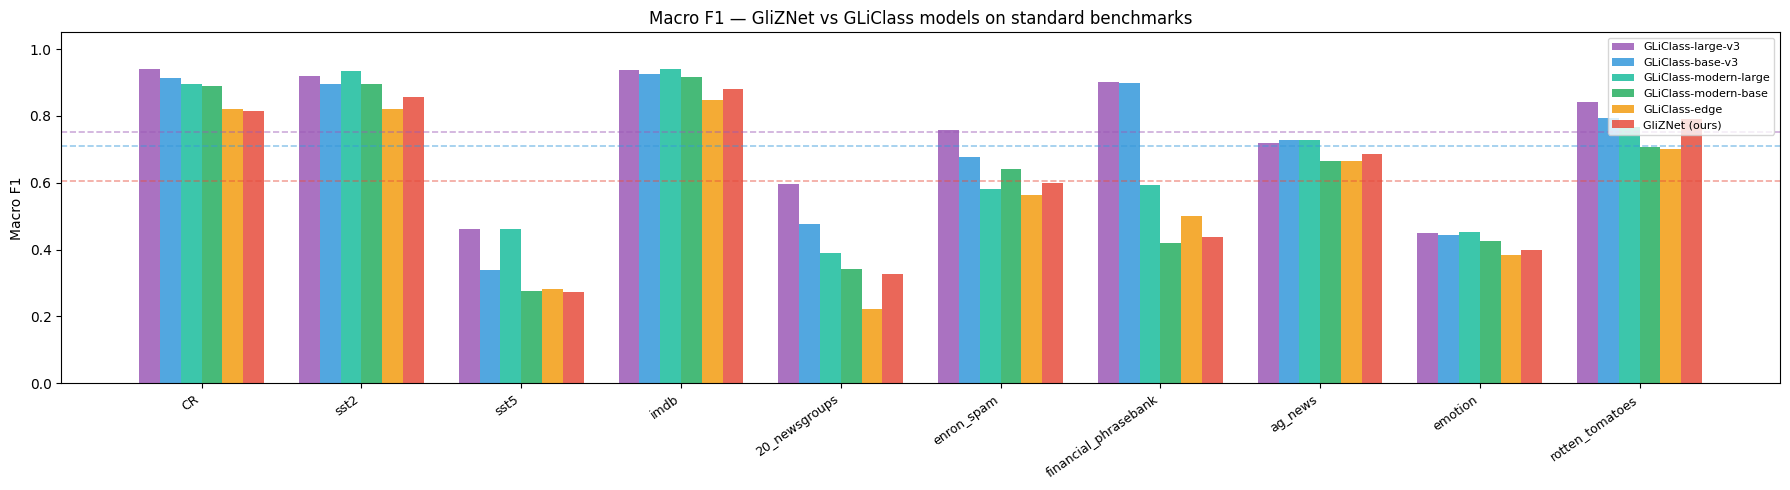


GliZNet avg macro F1        : 0.6065
GLiClass-large avg          : 0.7520  (Δ -0.1455)
GLiClass-base avg           : 0.7087  (Δ -0.1022)
GLiClass-modern-large avg   : 0.6740  (Δ -0.0675)
GLiClass-modern-base avg    : 0.6179  (Δ -0.0114)
GLiClass-edge avg           : 0.5809  (Δ +0.0256)


In [10]:
plot_df = df.drop("AVERAGE").dropna()
x = np.arange(len(plot_df))
w = 0.13

fig, ax = plt.subplots(figsize=(18, 5))
offsets = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]
colors  = ["#9b59b6", "#3498db", "#1abc9c", "#27ae60", "#f39c12", "#e74c3c"]
cols    = ["GLiClass-large-v3", "GLiClass-base-v3",
           "GLiClass-modern-large", "GLiClass-modern-base",
           "GLiClass-edge", "GliZNet (ours)"]
labels  = ["GLiClass-large-v3", "GLiClass-base-v3",
           "GLiClass-modern-large", "GLiClass-modern-base",
           "GLiClass-edge", "GliZNet (ours)"]

for off, col, lbl, clr in zip(offsets, cols, labels, colors):
    ax.bar(x + off * w, plot_df[col], w, label=lbl, color=clr, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1.05)
ax.set_title("Macro F1 — GliZNet vs GLiClass models on standard benchmarks")
ax.legend(loc="upper right", fontsize=8)

gliznet_avg        = df.loc["AVERAGE", "GliZNet (ours)"]
glibase_avg        = df.loc["AVERAGE", "GLiClass-base-v3"]
glilarge_avg       = df.loc["AVERAGE", "GLiClass-large-v3"]
glimod_large_avg   = df.loc["AVERAGE", "GLiClass-modern-large"]
glimod_base_avg    = df.loc["AVERAGE", "GLiClass-modern-base"]
gliedge_avg        = df.loc["AVERAGE", "GLiClass-edge"]

ax.axhline(gliznet_avg,  color="#e74c3c", ls="--", lw=1.2, alpha=0.5)
ax.axhline(glibase_avg,  color="#3498db", ls="--", lw=1.2, alpha=0.5)
ax.axhline(glilarge_avg, color="#9b59b6", ls="--", lw=1.2, alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nGliZNet avg macro F1        : {gliznet_avg:.4f}")
print(f"GLiClass-large avg          : {glilarge_avg:.4f}  (Δ {gliznet_avg - glilarge_avg:+.4f})")
print(f"GLiClass-base avg           : {glibase_avg:.4f}  (Δ {gliznet_avg - glibase_avg:+.4f})")
print(f"GLiClass-modern-large avg   : {glimod_large_avg:.4f}  (Δ {gliznet_avg - glimod_large_avg:+.4f})")
print(f"GLiClass-modern-base avg    : {glimod_base_avg:.4f}  (Δ {gliznet_avg - glimod_base_avg:+.4f})")
print(f"GLiClass-edge avg           : {gliedge_avg:.4f}  (Δ {gliznet_avg - gliedge_avg:+.4f})")
